# NASA Asteroid Sınıflandırma Projesi
## Notebook 01 — Ortam Kurulumu & Keşifsel Veri Analizi (EDA)

**Bu notebook'ta yapacaklarımız:**
1. Gerekli kütüphaneleri yükleme
2. NASA JPL asteroid verisini indirme
3. Veriyi ilk kez inceleme (shape, dtypes, null değerler)
4. Orbital parametreleri anlama
5. Hedef değişkenin dağılımını görme (sınıf dengesizliği!)
6. Korelasyon ısı haritası
7. Histogram ve box plot görselleştirmeleri
8. Veri temizleme ve preprocessing

> **Not:** Bu notebook Google Colab'da çalıştırılmak üzere hazırlanmıştır.

## 1. Kurulum — Kütüphane Yükleme

In [1]:
# Colab'da eksik olan kütüphaneleri yükle
!pip install spiceypy imbalanced-learn shap plotly xgboost lightgbm -q

print('✅ Kütüphaneler hazır!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 86.4 MB/s eta 0:00:00
✅ Kütüphaneler hazır!


In [2]:
# Temel import'lar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

# Görsel stil ayarları
plt.style.use('dark_background')
sns.set_palette('husl')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 50)

print('✅ Import işlemi tamamlandı!')

✅ Import işlemi tamamlandı!


## 2. Veri İndirme

Veriyi **Kaggle** üzerinden indireceğiz.

---
**Kaggle Dataset:** https://www.kaggle.com/datasets/sameepvani/nasa-nearest-earth-objects  
Dosya adı: `neo_v2.csv`

In [3]:
from google.colab import files

# Aşağıdaki satırın yorumunu kaldırarak dosya yükleme penceresi aç:
uploaded = files.upload()  # neo_v2.csv'yi seç

# Yüklendikten sonra:
df = pd.read_csv('neo_v2.csv')

print(f'Satır: {df.shape[0]:,} | Sütun: {df.shape[1]}')

Saving neo_v2.csv to neo_v2.csv
Satır: 90,836 | Sütun: 10


## 3. İlk Bakış — Veri Yapısını Anlama

In [4]:
# Temel bilgiler
print(f'Boyut: {df.shape[0]:,} satır × {df.shape[1]} sütun')
print('\nSütun tipleri:')
print(df.dtypes)
#df.info(show_counts=False)

print('\nİlk 5 satır:')
df.head()

Boyut: 90,836 satır × 10 sütun

Sütun tipleri:
id                      int64
name                   object
est_diameter_min      float64
est_diameter_max      float64
relative_velocity     float64
miss_distance         float64
orbiting_body          object
sentry_object            bool
absolute_magnitude    float64
hazardous                bool
dtype: object

İlk 5 satır:


,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.1983,2.6794,13569.2492,54839744.0828,Earth,False,16.7300,False
1,2277475,277475 (2005 WK4),0.2658,0.5943,73588.7267,61438126.5240,Earth,False,20.0000,True
2,2512244,512244 (2015 YE18),0.7220,1.6145,114258.6921,49798724.9405,Earth,False,17.8300,False
3,3596030,(2012 BV13),0.0965,0.2158,24764.3031,25434972.7208,Earth,False,22.2000,False
4,3667127,(2014 GE35),0.2550,0.5702,42737.7338,46275567.0013,Earth,False,20.0900,True


In [5]:
# İstatistiksel özet
print('İstatistiksel Özet:')
df.describe()

İstatistiksel Özet:


,id,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude
count,90836.0000,90836.0000,90836.0000,90836.0000,90836.0000,90836.0000
mean,14382878.0522,0.1274,0.2849,48066.9189,37066546.0304,23.5271
std,20872018.3539,0.2985,0.6675,25293.2970,22352040.5992,2.8941
min,2000433.0000,0.0006,0.0014,203.3464,6745.5325,9.2300
25%,3448110.0000,0.0193,0.0431,28619.0206,17210820.2358,21.3400
50%,3748362.0000,0.0484,0.1082,44190.1179,37846579.2634,23.7000
75%,3884023.0000,0.1434,0.3207,62923.6046,56548996.4514,25.7000
max,54275914.0000,37.8926,84.7305,236990.1281,74798651.4522,33.2000


In [6]:
# Eksik değer analizi
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)

null_df = pd.DataFrame({
    'Eksik Sayı': null_counts,
    'Eksik Yüzde (%)': null_pct
}).sort_values('Eksik Sayı', ascending=False)

print('🔴 Eksik Değer Analizi:')
print(null_df[null_df['Eksik Sayı'] > 0])

# Görselleştir
if null_df['Eksik Sayı'].sum() > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    cols_with_null = null_df[null_df['Eksik Sayı'] > 0]
    ax.barh(cols_with_null.index, cols_with_null['Eksik Yüzde (%)'], color='#FF6B6B')
    ax.set_xlabel('Eksik Değer Oranı (%)')
    ax.set_title('🔴 Sütunlara Göre Eksik Değer Oranı')
    for i, v in enumerate(cols_with_null['Eksik Yüzde (%)']):
        ax.text(v + 0.1, i, f'{v:.1f}%', va='center')
    plt.tight_layout()
    plt.show()
else:
    print('✅ Eksik değer yok!')

🔴 Eksik Değer Analizi:
Empty DataFrame
Columns: [Eksik Sayı, Eksik Yüzde (%)]
Index: []
✅ Eksik değer yok!


## 5. Hedef Değişken — Sınıf Dengesizliği Analizi

🎯 Hedef Değişken Dağılımı:
            Sayı   Yüzde
hazardous               
0          81996 90.2700
1           8840  9.7300


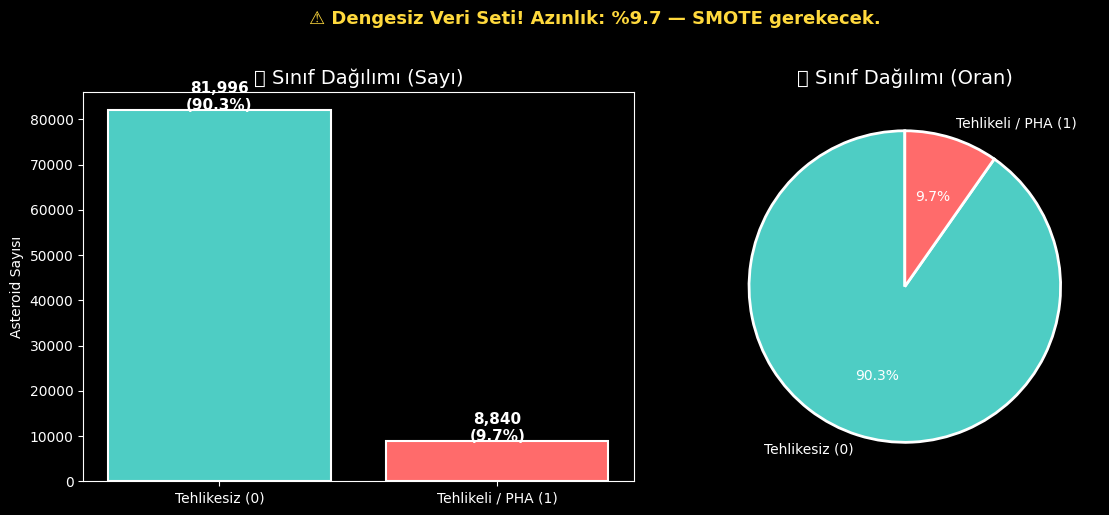


⚠️ Azınlık sınıfı oranı: %9.7
→ Sadece "tehlikesiz" tahmin eden model bile %90.3 accuracy elde eder!
→ Bu yüzden Recall ve F1 metriklerine odaklanacağız.


In [7]:
# Hedef değişkeni belirle (gerçek veri setinde 'hazardous' veya 'pha' olabilir)
TARGET = 'hazardous'  # Gerçek veri için 'pha' olabilir → Y/N'yi 1/0'a çevirmeyi unutma

df[TARGET] = df[TARGET].astype(int)

# Dağılım
counts = df[TARGET].value_counts()
pct = df[TARGET].value_counts(normalize=True) * 100

print('🎯 Hedef Değişken Dağılımı:')
print(pd.DataFrame({'Sayı': counts, 'Yüzde': pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
colors = ['#4ECDC4', '#FF6B6B']
labels = ['Tehlikesiz (0)', 'Tehlikeli / PHA (1)']
axes[0].bar(labels, counts.sort_index(), color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('🎯 Sınıf Dağılımı (Sayı)', fontsize=14)
axes[0].set_ylabel('Asteroid Sayısı')
for i, v in enumerate(counts.sort_index()):
    axes[0].text(i, v + 50, f'{v:,}\n({pct.sort_index().iloc[i]:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(counts.sort_index(), labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('🎯 Sınıf Dağılımı (Oran)', fontsize=14)

minority_pct = pct.min()
if minority_pct < 30:
    baslik = f'⚠️ Dengesiz Veri Seti! Azınlık: %{minority_pct:.1f} — SMOTE gerekecek.'
    renk = '#FFD93D'
elif minority_pct < 40:
    baslik = f'⚠️ Hafif Dengesizlik: Azınlık sınıfı %{minority_pct:.1f}'
    renk = '#FFA500'
else:
    baslik = f'✅ Dengeli Veri Seti: %{minority_pct:.1f} / %{100 - minority_pct:.1f}'
    renk = '#4ECDC4'

plt.suptitle(baslik, fontsize=13, color=renk, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


print(f'\n⚠️ Azınlık sınıfı oranı: %{minority_pct:.1f}')
print('→ Sadece "tehlikesiz" tahmin eden model bile %{:.1f} accuracy elde eder!'.format(100 - minority_pct))
print('→ Bu yüzden Recall ve F1 metriklerine odaklanacağız.')

## 6. Korelasyon Isı Haritası

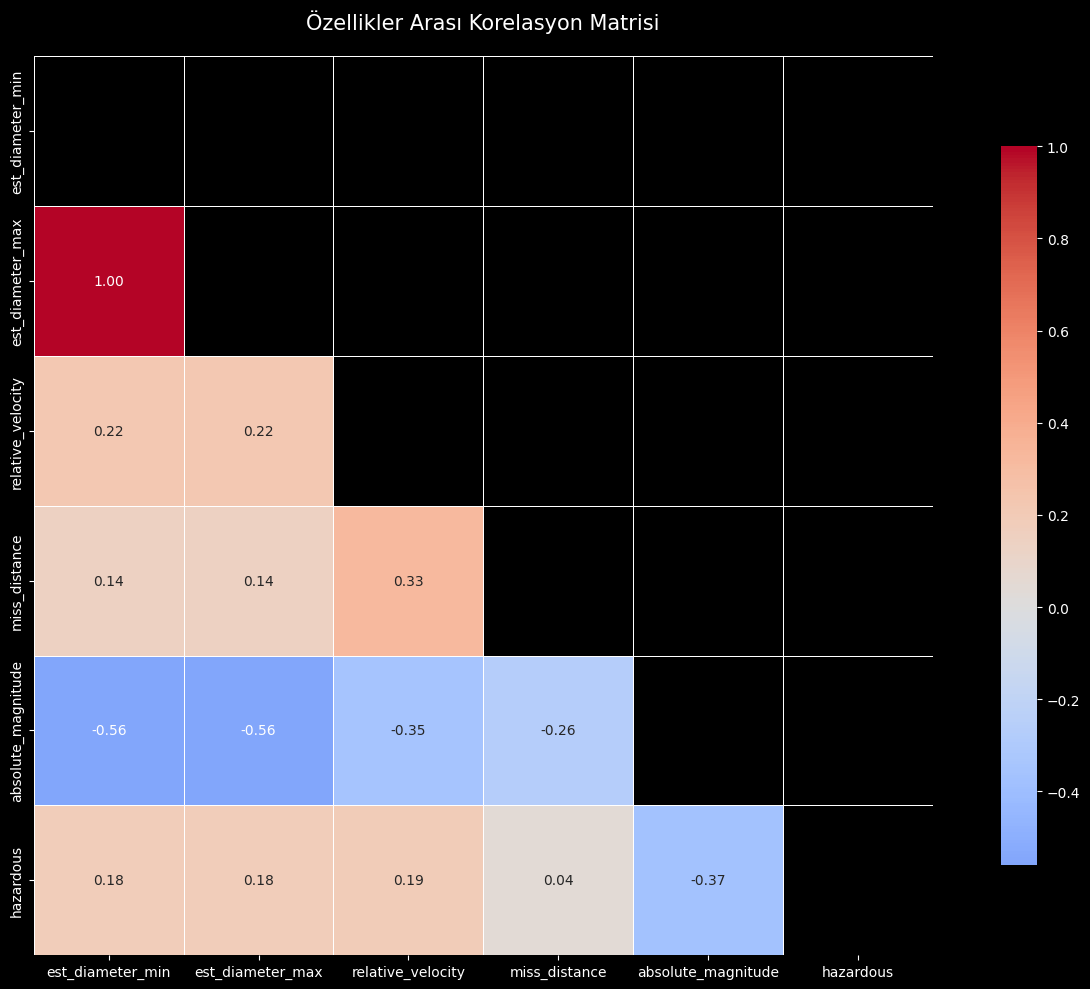


🎯 Hedef değişken ile en yüksek korelasyonlu özellikler:
absolute_magnitude   -0.3653
relative_velocity     0.1912
est_diameter_max      0.1834
est_diameter_min      0.1834
miss_distance         0.0423
Name: hazardous, dtype: float64


In [8]:
# Sayısal sütunları seç
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# ID sütunlarını çıkar
numeric_cols = [c for c in numeric_cols if 'id' not in c.lower() and 'name' not in c.lower()]

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Üst üçgeni gizle

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    ax=ax
)

ax.set_title('Özellikler Arası Korelasyon Matrisi', fontsize=15, pad=20)
plt.tight_layout()
plt.show()

# Hedef ile en yüksek korelasyonlu özellikler
if TARGET in corr_matrix.columns:
    target_corr = corr_matrix[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
    print('\n🎯 Hedef değişken ile en yüksek korelasyonlu özellikler:')
    print(target_corr.head(10))

## 7. Histogram — Her Özelliğin Dağılımı

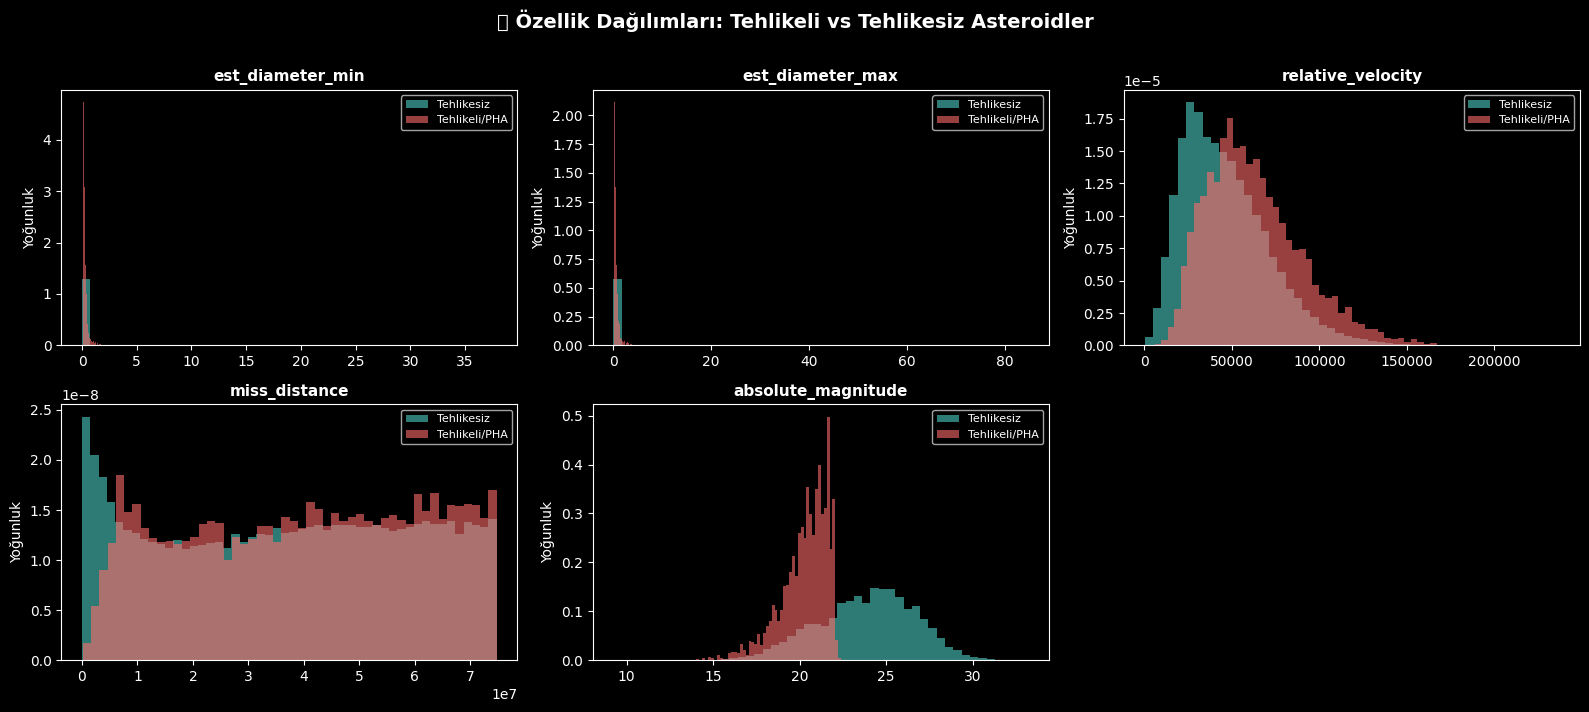

💡 İpucu: İki sınıf arasında dağılımı en farklı olan özellikler en ayırt edici olanlardır!


In [9]:
# Sayısal sütunların histogramı (PHA vs Non-PHA kıyaslamalı)
feature_cols = [c for c in numeric_cols if c != TARGET]

n_cols = 3
n_rows = (len(feature_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for idx, col in enumerate(feature_cols):
    ax = axes[idx]
    for label, color, name in [(0, '#4ECDC4', 'Tehlikesiz'), (1, '#FF6B6B', 'Tehlikeli/PHA')]:
        subset = df[df[TARGET] == label][col].dropna()
        ax.hist(subset, bins=50, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=8)
    ax.set_ylabel('Yoğunluk')

# Boş subplot'ları gizle
for idx in range(len(feature_cols), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('📊 Özellik Dağılımları: Tehlikeli vs Tehlikesiz Asteroidler',
             fontsize=14, y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()
print('💡 İpucu: İki sınıf arasında dağılımı en farklı olan özellikler en ayırt edici olanlardır!')

## 8. Box Plot — Aykırı Değer Tespiti

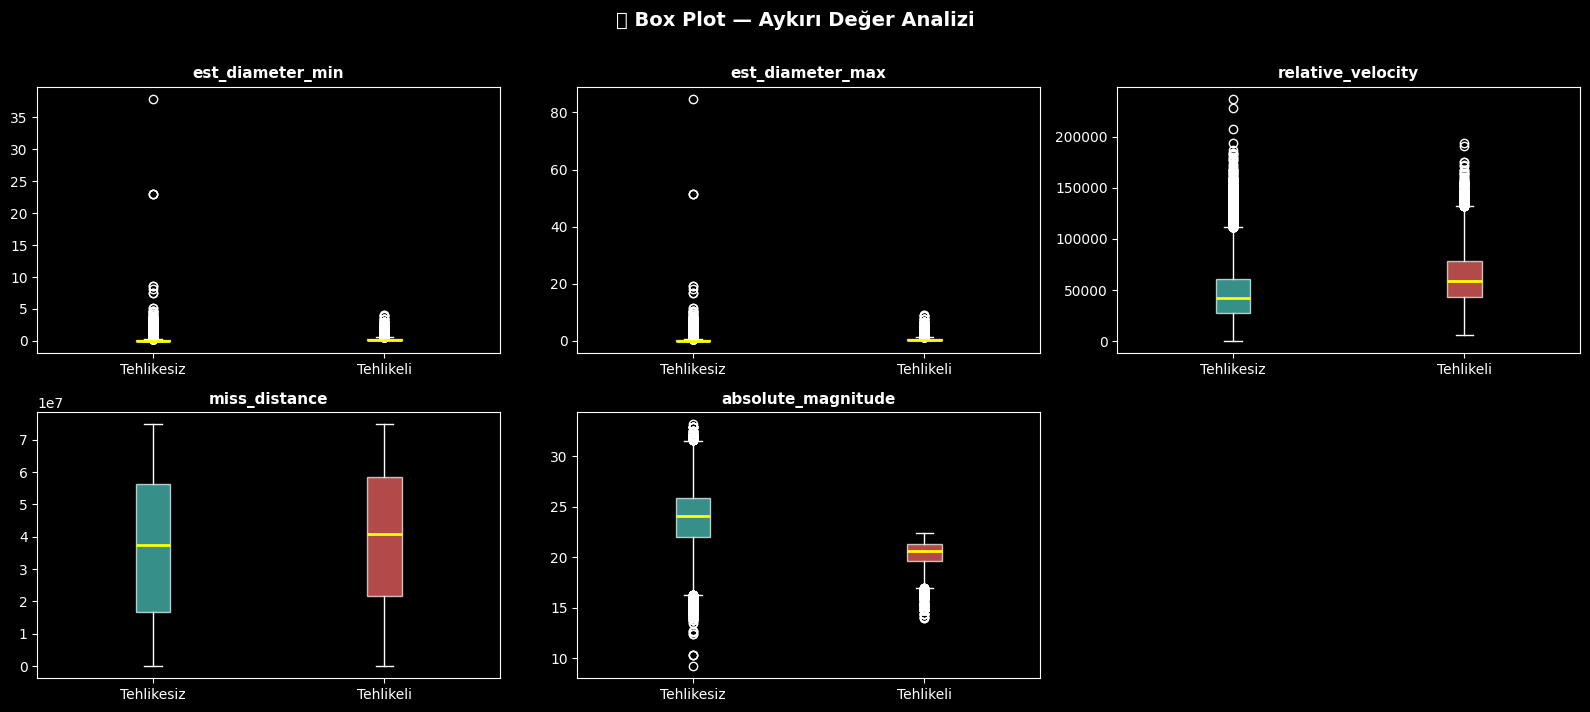

In [10]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for idx, col in enumerate(feature_cols):
    ax = axes[idx]
    data_to_plot = [df[df[TARGET] == 0][col].dropna(),
                    df[df[TARGET] == 1][col].dropna()]
    bp = ax.boxplot(data_to_plot, labels=['Tehlikesiz', 'Tehlikeli'],
                    patch_artist=True, notch=False,
                    medianprops={'color': 'yellow', 'linewidth': 2})
    bp['boxes'][0].set_facecolor('#4ECDC4')
    bp['boxes'][0].set_alpha(0.7)
    if len(bp['boxes']) > 1:
        bp['boxes'][1].set_facecolor('#FF6B6B')
        bp['boxes'][1].set_alpha(0.7)
    ax.set_title(col, fontsize=11, fontweight='bold')

for idx in range(len(feature_cols), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('📦 Box Plot — Aykırı Değer Analizi', fontsize=14, y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Veri Temizleme & Preprocessing

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# --- 1. Gereksiz sütunları at ---
drop_cols = ['id', 'name','est_diameter_min','est_diameter_max', 'neo_reference_id', 'orbiting_body', 'sentry_object']
drop_cols = [c for c in drop_cols if c in df.columns]  # Sadece var olanları at
df_clean = df.drop(columns=drop_cols, errors='ignore').copy()
print(f'Atılan sütunlar: {drop_cols}')

# --- 2. Hedef değişkeni ayır ---
X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET].astype(int)

# --- 3. Sayısal sütunları seç ---
X = X.select_dtypes(include=[np.number])
print(f'\nÖzellik sayısı: {X.shape[1]}')
print(f'Özellikler: {list(X.columns)}')

# --- 4. Eksik değerleri doldur (medyan) ---
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)
X = pd.DataFrame(X_imputed, columns=X.columns)
print(f'\n✅ Eksik değerler medyan ile dolduruldu.')
print(f'Kalan null sayısı: {X.isnull().sum().sum()}')

# --- 5. Aykırı değerleri IQR ile tespit et ve raporla ---
outlier_report = {}
for col in X.columns:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((X[col] < lower) | (X[col] > upper)).sum()
    if n_outliers > 0:
        outlier_report[col] = n_outliers

print('\n🔴 Aykırı değer sayıları (IQR yöntemi):')
for col, n in sorted(outlier_report.items(), key=lambda x: -x[1]):
    print(f'  {col:30s}: {n:5,} aykırı değer')
print('→ Orbital parametreler için aykırı değerleri silmek yerine fiziksel kısıtlamalara bak.')

# --- 6. Train/Test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify ile oranı koru!
)

# --- 7. Feature scaling ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Sadece train üzerinde fit!
X_test_scaled = scaler.transform(X_test)         # Test'e sadece transform

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print(f'\n✅ Preprocessing tamamlandı!')
print(f'Train seti: {X_train_scaled.shape[0]:,} satır | Test seti: {X_test_scaled.shape[0]:,} satır')
print(f'Train PHA oranı: %{y_train.mean()*100:.1f}')
print(f'Test PHA oranı: %{y_test.mean()*100:.1f}')

Atılan sütunlar: ['id', 'name', 'est_diameter_max', 'orbiting_body', 'sentry_object']

Özellik sayısı: 4
Özellikler: ['est_diameter_min', 'relative_velocity', 'miss_distance', 'absolute_magnitude']

✅ Eksik değerler medyan ile dolduruldu.
Kalan null sayısı: 0

🔴 Aykırı değer sayıları (IQR yöntemi):
  est_diameter_min              : 8,306 aykırı değer
  relative_velocity             : 1,574 aykırı değer
  absolute_magnitude            :   101 aykırı değer
→ Orbital parametreler için aykırı değerleri silmek yerine fiziksel kısıtlamalara bak.

✅ Preprocessing tamamlandı!
Train seti: 72,668 satır | Test seti: 18,168 satır
Train PHA oranı: %9.7
Test PHA oranı: %9.7


In [13]:
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_PATH = '/content/drive/MyDrive/nasa_asteroid/'
os.makedirs(DRIVE_PATH, exist_ok=True)

# Temizlenmiş veriyi kaydet (sonraki notebook'lar için)
X_train_scaled.to_csv(DRIVE_PATH + 'X_train.csv', index=False)
X_test_scaled.to_csv(DRIVE_PATH + 'X_test.csv', index=False)
y_train.to_csv(DRIVE_PATH + 'y_train.csv', index=False)
y_test.to_csv(DRIVE_PATH + 'y_test.csv', index=False)

# Scaler'ı kaydet
import pickle
with open(DRIVE_PATH + 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('💾 Veriler Google Drive/nasa_asteroid/ klasörüne kaydedildi:')
print('  ✅ X_train.csv, X_test.csv')
print('  ✅ y_train.csv, y_test.csv')
print('  ✅ scaler.pkl')
print('\n🚀 Notebook 01 tamamlandı! Sıradaki adım: 02_baseline_models_shap.ipynb')

Mounted at /content/drive
💾 Veriler Google Drive/nasa_asteroid/ klasörüne kaydedildi:
  ✅ X_train.csv, X_test.csv
  ✅ y_train.csv, y_test.csv
  ✅ scaler.pkl

🚀 Notebook 01 tamamlandı! Sıradaki adım: 02_baseline_models_shap.ipynb



## 📋 Bu Notebook'tan Çıkarımlar

| Bulgu | Önemi |
|-------|-------|
| Sınıf dengesizliği (%9.7 PHA) | SMOTE gerekecek |
| Eksik değerler | Medyan imputation yeterli |
| Aykırı değerler | Orbital parametreler için fiziksel sınırlar kullan |
| MOID + H en belirleyici | SHAP bunu onaylayacak mı? |

- Kullanılan veri setinde MOID değeri doğrudan yer almamaktadır. Ancak tehlikelilik etiketi NASA JPL tarafından MOID ≤ 0.05 AU ve H ≤ 22 kriterleri gözetilerek atandığından, bu bilgi hedef değişkene dolaylı olarak yansımaktadır. Analizde MOID'e en yakın gösterge olarak miss_distance özelliği kullanılmıştır.

### ⏭️ Sıradaki Notebook
`02_baseline_models_shap.ipynb` → Logistic Regression, Random Forest, XGBoost eğitimi + SHAP analizi

### 📚 Raporun İçin Not Et
- Veri boyutu ve kaynak
- Sınıf dengesizliği oranı ve bunun yarattığı sorun
- Hangi özelliklerin hedefle en yüksek korelasyon gösterdiği
- Preprocessing kararları ve gerekçeleri